# Name: Andrew Dai
### Date: 9/9/2025

<style>
.jp-Notebook {
    padding: var(--jp-notebook-padding);
    margin-left: 160px;
    outline: none;
    overflow: auto;
    background: var(--jp-layout-color0);
}
</style>

<img src="https://cdn.nba.com/logos/nba/1610612760/primary/L/logo.svg" alt="logo" style="position: fixed; top: -40px; left: 5px; height: 250px;">

# Introduction  

The purpose of this project is to gauge your technical skills and problem solving ability by working through something similar to a real NBA data science project. You will work your way through this R Markdown document, answering questions as you go along. Please begin by adding your name to the "author" key in the YAML header. When you're finished with the document, come back and type your answers into the answer key at the top. Please leave all your work below and have your answers where indicated below as well. Please note that we will be reviewing your code so make it clear, concise, and **avoid long printouts.** Feel free to add in as many new code chunks as you'd like.

Remember that we will be grading the quality of your code and visuals alongside the correctness of your answers. Please try to use the tidyverse as much as possible (instead of base R and explicit loops). Please do not bring in any outside data, and use the provided data as truth (for example, some "home" games have been played at secondary locations, including TOR's entire 2020-21 season. These are not reflected in the data and you do not need to account for this.) Note that the OKC and DEN 2024-25 schedules in `schedule_24_partial.csv` intentionally include only 80 games, as the league holds 2 games out for each team in the middle of December due to unknown NBA Cup matchups. Do not assign specific games to fill those two slots.      

**Note:**    

**Throughout this document, any `season` column represents the year each season started. For example, the 2015-16 season will be in the dataset as 2015. We may refer to a season by just this number (e.g. 2015) instead of the full text (e.g. 2015-16).**   

# Answers  

## Part 1      

**Question 1:** 26 4-in-6 stretches in OKC's draft schedule.   

**Question 2:** 25.1 4-in-6 stretches on average.  

**Question 3:**    

- Most 4-in-6 stretches on average: Charlotte Hornets (28.11)
- Fewest 4-in-6 stretches on average: New York Knicks (22.19)    

**Question 4:** This is a written question. Please leave your response in the document under Question 4.          

**Question 5:**   

- BKN Defensive eFG%: 54.51%
- When opponent on a B2B: 53.63%

## Part 2  

Please show your work in the document, you don't need anything here.     

## Part 3    
 
**Question 8:**    

- Most Helped by Schedule: MIL (36.6 wins)
- Most Hurt by Schedule: SAS (-36.29 wins)

# Setup and Data    

In [1]:
import pandas as pd
# Note, you will likely have to change these paths. If your data is in the same folder as this project, 
# the paths will likely be fixed for you by deleting ../../Data/schedule_project/ from each string.
schedule = pd.read_csv("schedule.csv")
draft_schedule = pd.read_csv("schedule_24_partial.csv")
locations = pd.read_csv("locations.csv")
game_data = pd.read_csv("team_game_data.csv")

## Part 1 -- Schedule Analysis               

In this section, you're going to work to answer questions using NBA scheduling data.   

### Question 1  

**QUESTION:** How many times are the Thunder scheduled to play 4 games in 6 nights in the provided 80-game draft of the 2024-25 season schedule? (Note: clarification, the stretches can overlap, the question is really “How many games are the 4th game played over the past 6 nights?”)     

 

In [2]:
# Rolling day function: Input (dataframe, column_name), outputs counts of 4-in-6 games
# Logic loosely references linked list data structure and underlying logic was made with GPT 
def four_in_six(df, col="gamedate"):
    df[col] = pd.to_datetime(df[col])
    dates = df[col].sort_values().to_list()
    count = 0 # count of 4-in-6 games
    start = 0 # index of first game in curr

    # General logic: iterate through every gametime. If gametime start pointer is more than 5 days behind
    # end pointer, add 1 to it so it stays within that 6 day window. If there are for games between the end
    # and start pointer, +=1 to count. 
    for end, d in enumerate(dates): # end = index, d = current game date
        while (d - dates[start]).days > 5:
            start += 1
        # If window contains 4 games, add to count
        if end - start + 1 == 4:
            count += 1
    return count

In [3]:
# Filter for only OKC games
okc_games = draft_schedule[draft_schedule['team'] == 'OKC'].copy()
okc_4_in_6 = four_in_six(okc_games)

In [4]:
print("Num of games that are 4th within 6 nights is", okc_4_in_6)

Num of games that are 4th within 6 nights is 26


<strong><span style="color:red">ANSWER 1:</span></strong>   

26 4-in-6 stretches in OKC's draft schedule.   

### Question 2     

**QUESTION:** From 2014-15 to 2023-24, what is the average number of 4-in-6 stretches for a team in a season? Adjust each team/season to per-82 games before taking your final average.   
  


In [5]:
# Calculate 4-in-6 per every team-season
per_82 = schedule.groupby(['team', 'season']).agg(
    games_played=('gamedate', 'count'),
    four_in_6=('gamedate', lambda x: four_in_six(x.to_frame(), col="gamedate"))
).reset_index()
# Adjust per-82 games
per_82['four_in_6_per82'] = per_82['four_in_6'] * 82 / per_82['games_played']

In [6]:
# Compute average for every 4-in-6
average = per_82['four_in_6_per82'].mean()
print("Avg num of 4-in-6 stretches per team-season is", round(average, 2))

Avg num of 4-in-6 stretches per team-season is 25.1


<strong><span style="color:red">ANSWER 2:</span></strong>  

25.1 4-in-6 stretches on average.  

### Question 3  

**QUESTION:** Which of the 30 NBA teams has had the highest average number of 4-in-6 stretches between 2014-15 and 2023-24? Which team has had the lowest average? Adjust each team/season to per-82 games.     


In [7]:
# Take averages of 4-in-6 counts per team (between 2014-2024)
team_avg = per_82.groupby('team').agg(four_in_6_avg = ('four_in_6_per82', 'mean'))
team_avg = team_avg.sort_values('four_in_6_avg', ascending=False).round(2)

# Fetch top team & 4-in-6 average
high_team = team_avg.index[0]
high_avg = team_avg.iloc[0,0]
# Fetch bottom team & 4-in-6 average
low_team = team_avg.index[-1]
low_avg = team_avg.iloc[-1,0]

print("The highest average team of 4-in-6 stretches is", high_team, high_avg)
print("The lowest average team of 4-in-6 stretches is", low_team, low_avg)

The highest average team of 4-in-6 stretches is CHA 28.11
The lowest average team of 4-in-6 stretches is NYK 22.19


<strong><span style="color:red">ANSWER 3:</span></strong>  

- Most 4-in-6 stretches on average: Charlotte Hornets (28.11)     
- Fewest 4-in-6 stretches on average: New York Knicks (22.19)       

### Question 4  

**QUESTION:** Is the difference between most and least from Q3 surprising, or do you expect that size difference is likely to be the result of chance?    

In [8]:
# Needed for permutation test
import matplotlib.pyplot as plt
import numpy as np

In [9]:
### Permutation Test for difference in avg 4-in-6
# The above assumes NBA randomly generates game schedules

# Observed difference = (highest avg team 4-in-6) - (lowest avg team 4-in-6)
obs_diff = high_avg - low_avg
print("Observed difference is", round(obs_diff,2))

# Run 1000 permutations, aka re-simulating the data
diffs = [] # Collects all simulated differences
for i in range(1000):
    shuffled = np.random.permutation(per_82["four_in_6_per82"].values) # run perm
    fake = per_82.assign(fake_counts=shuffled) # create copy of per_82 df and append new column with permuted values
    fake_avg = fake.groupby("team")["fake_counts"].mean()
    diffs.append(fake_avg.max() - fake_avg.min())

# Calculate p-value
p_value = (np.array(diffs) >= obs_diff).mean()
print("P-value is", p_value)

Observed difference is 5.92
P-value is 0.868


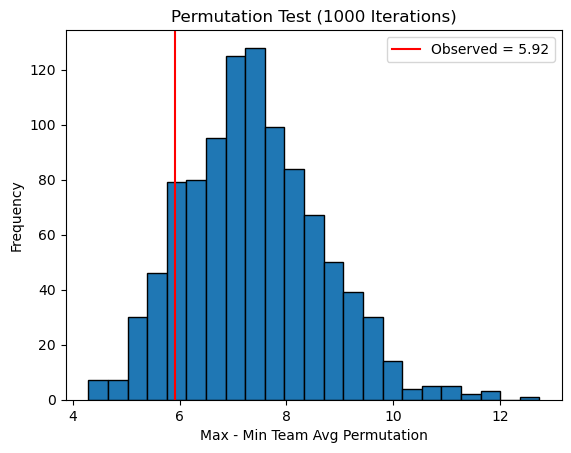

In [10]:
# Plot permutations
plt.hist(diffs, bins=23, edgecolor="black")
plt.title("Permutation Test (1000 Iterations)")
plt.xlabel("Max - Min Team Avg Permutation")
plt.ylabel("Frequency")
plt.axvline(obs_diff, color="red", label=f"Observed = {obs_diff:.2f}")
plt.legend()
plt.show()

<strong><span style="color:red">ANSWER 4:</span></strong>  The difference is not suprising and is likely to be due to chance. Referring to the frequency histogram above, I simulated the data 1000 times and binned the frequency of simulated team average differences (Max - min). The red line indicates the real difference I observed in Q3. Since the real difference was relatively close to the mode difference (about 7.5), we can infer that the original different is not an anomoly. If you re-run the code several times, you'll get p-values roughly between 0.88-0.92, indicating that the real, observed difference is likely to due to chance rather than any deliberate cause. 

### Question 5   

**QUESTION:** What was BKN's defensive eFG% in the 2023-24 season? What was their defensive eFG% that season in situations where their opponent was on the second night of back-to-back?  

In [11]:
### Data Cleaning

# Fetch BKN for 2023-2024 season + Convert dates to datetime
schedule_BKN = schedule[(schedule['team']=='BKN') & (schedule['season']==2023)].copy()
schedule_BKN['gamedate'] = pd.to_datetime(schedule_BKN['gamedate'])
schedule['gamedate'] = pd.to_datetime(schedule['gamedate'])
game_data['gamedate'] = pd.to_datetime(game_data['gamedate'])

### Feature Engineering - b2b boolean

# Mark true/false if opponent was b2b on 2nd night
schedule_sorted = schedule.sort_values(['team','gamedate'])
# for every gamedate, pull prev game's gamedate
schedule_sorted['prev_date'] = schedule_sorted.groupby('team')['gamedate'].shift(1)
# Check for 2nd b2b opponents (if diff between curr date and previous date is 1, true)
schedule_sorted['b2b'] = (
    (schedule_sorted['gamedate'] - schedule_sorted['prev_date']).dt.days == 1
).fillna(False)

In [12]:
# Merge B2B Feature into BKN schedule (per team-season)
schedule_BKN = schedule_BKN.merge(
    schedule_sorted[['team','gamedate','b2b']],
    left_on=['opponent','gamedate'],
    right_on=['team','gamedate'],
    how='left',
    suffixes=('','_opp') # feature differentiate values from left & right dfs
)
# Merge game data into BKN schedule
merged_df = pd.merge(
    game_data,
    schedule_BKN,
    left_on=['def_team', 'off_team', 'gamedate'],
    right_on=['team', 'opponent', 'gamedate'],
    how='right'
)

In [13]:
# Remember DEFENSIVE eFG%!!! (eFG% BKN allows)
# General formula: eFG% = (FGM + 0.5 * 3PM) / FGA
# Corresponding variables: FGM = fg2made + fg3made, 3PM = fg3made, FGA = fgattempted
FGM = merged_df['fg2made'] + merged_df['fg3made']
PM3 = merged_df['fg3made']
FGA = merged_df['fgattempted']
merged_df['def_eFG'] = (FGM + 0.5 * PM3) / FGA

# Calculate means of all games def_eFG & vs opponents on 2nd b2b game def_eFG. 
total_def_eFG = round(merged_df['def_eFG'].mean() * 100 ,2)
b2b_def_eFG = round(merged_df.loc[merged_df['b2b']]['def_eFG'].mean() * 100,2)
print("BKN Defensive eFG% (2023-24) is", total_def_eFG)
print("BKN Defensive eFG% v. Opponent on 2nd B2B Game is", b2b_def_eFG)

BKN Defensive eFG% (2023-24) is 54.51
BKN Defensive eFG% v. Opponent on 2nd B2B Game is 53.63


<strong><span style="color:red">ANSWER 5:</span></strong>  

- BKN Defensive eFG%: 54.51%   
- When opponent on a B2B: 53.63%    

## Part 2 -- Trends and Visualizations                   

This is an intentionally open ended section, and there are multiple approaches you could take to have a successful project. Feel free to be creative. However, for this section, please consider only the density of games and travel schedule, not the relative on-court strength of different teams.    

### Question 6   

**QUESTION:** Please identify at least 2 trends in scheduling over time. In other words, how are the more recent schedules different from the schedules of the past? Please include a visual (plot or styled table) highlighting or explaining each trend and include a brief written description of your findings.  


In [14]:
### Run this cell only once!
# Uncomment this line to install geopy (for calculating distances for lat, lon data)
!pip install geopy
from geopy.distance import geodesic

In [15]:
# Convert datetime
schedule['gamedate'] = pd.to_datetime(schedule['gamedate'])

# Merge home_lat/lon and opp_lat/lon to schedule data
schedule_loc = schedule.merge(
    locations.rename(columns={'latitude': 'home_lat', 'longitude': 'home_lon'}),
    left_on='team', right_on='team', how='left'
).merge(
    locations.rename(columns={'latitude': 'opp_lat', 'longitude': 'opp_lon'}),
    left_on='opponent', right_on='team', how='left',
    suffixes=('', '_opp')
)

# Create actual game location (home arena if home==1 else opponent arena)
schedule_loc['game_lat'] = np.where(schedule_loc['home']==1, schedule_loc['home_lat'], schedule_loc['opp_lat'])
schedule_loc['game_lon'] = np.where(schedule_loc['home']==1, schedule_loc['home_lon'], schedule_loc['opp_lon'])

# Drop unnecesary columns and sort
schedule_loc = schedule_loc[['season', 'gamedate', 'team', 'opponent', 'home', 'game_lat', 'game_lon']]
schedule_loc = schedule_loc.sort_values(['team', 'gamedate']).reset_index(drop=True)

In [16]:
# Calculate travel distance (miles) between consec games per team
def calculate_travel(row):
    prev_lat = row['prev_lat']
    prev_lon = row['prev_lon']
    curr_lat = row['game_lat']
    curr_lon = row['game_lon']
    if pd.isna(prev_lat) or pd.isna(prev_lon):
        return 0
    else:
        return geodesic((prev_lat, prev_lon), (curr_lat, curr_lon)).miles

# Create new features of previous game location
schedule_loc['prev_lat'] = schedule_loc.groupby('team')['game_lat'].shift(1)
schedule_loc['prev_lon'] = schedule_loc.groupby('team')['game_lon'].shift(1)
schedule_loc['travel_miles'] = schedule_loc.apply(calculate_travel, axis=1)

In [17]:
# Aggregate total travel distance per team per season
travel_by_season = schedule_loc.groupby(['team', 'season'])['travel_miles'].sum().reset_index()

# Calculate mean travel miles per season
stats_by_season = travel_by_season.groupby('season')['travel_miles'].agg(
    mean='mean',
    variance='var'
).reset_index()

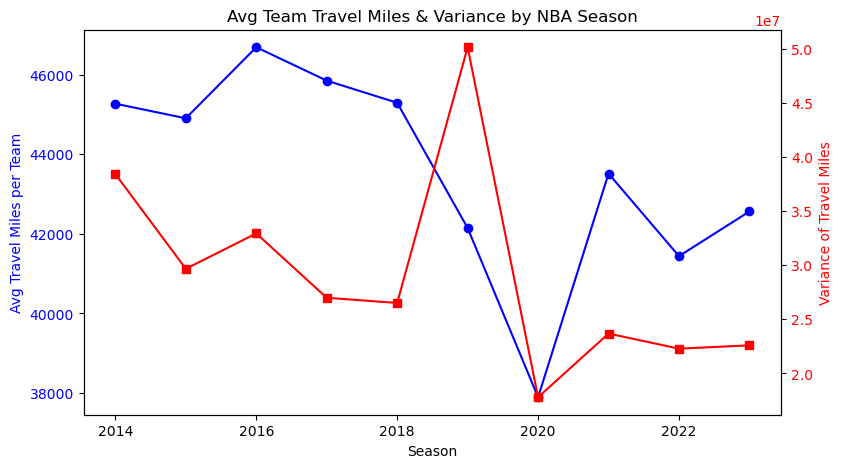

In [18]:
fig, ax1 = plt.subplots(figsize=(9,5))

# Plot mean travel
ax1.plot(stats_by_season['season'], stats_by_season['mean'],
         marker='o', color='blue', label='Mean Travel')
ax1.set_xlabel('Season')
ax1.set_ylabel('Avg Travel Miles per Team', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot travel variance between teams
ax2 = ax1.twinx()
ax2.plot(stats_by_season['season'], stats_by_season['variance'],
         marker='s', color='red', label='Variance')
ax2.set_ylabel('Variance of Travel Miles', color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.title('Avg Team Travel Miles & Variance by NBA Season')
plt.show()

<strong><span style="color:red">ANSWER 6:</span></strong> In the plot above, **Avg Team Travel Miles & Variance**, travel averages were typically stable before dropping sharply in 2019-2020. Within 2014 and 2019, miles were roughly around 45000 through 47000. The sharp drop in 2019-2020 season was due to Covid-19 which lead to scheduling disruptions, restrictions on flying, and the famous Orlando Bubble. 
<br>After 2020, there was a steep recovery in miles but they didn't match pre Covid 19 levels. This suggests that optimizing scheduling changes occured, for example, a higher frequency of closely clustered cities and less across nation flights. This is great as it allows players more time for rest and is less costly for teams. Additionally there's a super small spread, ever-decreasing trend in variance (red) as well, meaning that NBA is providing increasingly fair schedules where teams will not have minor health and cost advantages over others that have to travel more. 
<br> To develop a more nuanced, geographical approach to this data is to dig into occurences of road trips vs. across nation flights. I created a new feature for road-road game streak and/or geoplotting game_lat and game_lon geographics to represent a general graph to verify my previous suggestions were correct.

In [19]:
# Derived from mark_four_in_six - same logic except counting 4 back-to-back, away games.
# Returns df with column "road_trip" boolean.
def mark_roadtrip(df, col="home"):
    df = df.copy()
    df = df.sort_values("gamedate").reset_index(drop=True)

    # Initialize new column
    df["road_trip"] = False

    # Identify away games (assuming home=1 means home, 0 means away)
    away_mask = df[col] == 0

    # Track streaks of consecutive away games
    streak = 0
    for i, away in enumerate(away_mask):
        if away:
            streak += 1
            if streak >= 4:
                # Mark the current game and the previous two (and earlier if longer streak continues)
                df.loc[i - streak + 1 : i, "road_trip"] = True
        else:
            streak = 0  # reset if a home game
    return df

In [20]:
# Data Prep - Sort team and gamedate
schedule_sort = schedule.sort_values(by=["team", "gamedate"])

# Group by team and mark roadtrip column
team_roadtrips = (
    schedule_sort
    .groupby("team", group_keys=False)
    .apply(mark_roadtrip)
    .reset_index(drop=True)
)
team_roadtrips = (team_roadtrips.groupby(by=["season","team"])["road_trip"].sum().reset_index()
                 .groupby(by=['season'])['road_trip'].sum().reset_index())

/tmp/ipykernel_735/3605588232.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(mark_roadtrip)


Text(0, 0.5, 'Leauge-Wide Number of Road Trip Games')

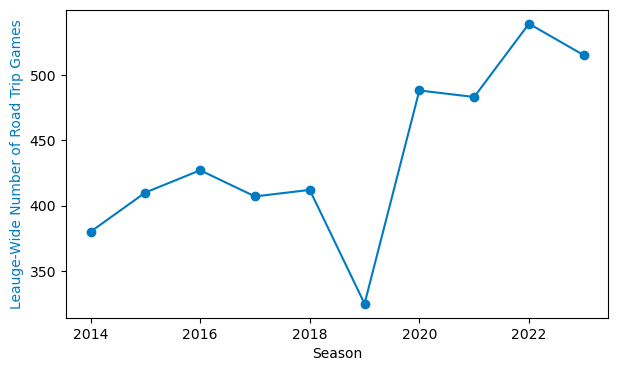

In [21]:
fig, ax1 = plt.subplots(figsize=(7,4))

# Plot mean travel
ax1.plot(team_roadtrips['season'], team_roadtrips['road_trip'],
         marker='o', color='#007AC1', label='Mean Travel')
ax1.set_xlabel('Season')
ax1.set_ylabel('Leauge-Wide Number of Road Trip Games', color='#007AC1')

This graph above shows a **positive rise in number of roadtrips** league wide. Games are marked True to be marked as part of a roadtrip if they are part of a 4+ away-game streak. This indicates NBA is scheduling more road-trips over long plane flights between home-away/away-home games. It's ideal for a team to have more of these road-trips as it's cheaper instead of booking more, longer plane flights and allows players to adjust to timezones if the games are in the same geographical timezone cluster. 

### Question 7    

**QUESTION:** Please design a plotting tool to help visualize a team’s schedule for a season. The plot should cover the whole season and should help the viewer contextualize and understand a team’s schedule, potentially highlighting periods of excessive travel, dense blocks of games, or other schedule anomalies. If you can, making the plots interactive (for example through the plotly package) is a bonus.   

Please use this tool to plot OKC and DEN's provided 80-game 2024-25 schedules.   

In [22]:
import plotly.express as px

In [23]:
# Modified function of OG four_in_six function
# Input df, column - Outputs df with appended four_in_six (boolean) column
def mark_four_in_six(df, col="gamedate"):
    df = df.copy()
    df[col] = pd.to_datetime(df[col])
    df = df.sort_values(col).reset_index(drop=True)

    # Default: not a 4-in-6
    df["four_in_six"] = False  
    dates = df[col].to_list()
    start = 0

    for end, d in enumerate(dates):
        # Slide window so it covers at most 6 days
        while (d - dates[start]).days > 5:
            start += 1

        # If window size == 4, only mark the 4th game (current one)
        if end - start + 1 == 4:
            df.loc[end, "four_in_six"] = True

    return df

In [24]:
# Convert gametime to datetime and sort gametimes
draft_schedule["gamedate"] = pd.to_datetime(draft_schedule["gamedate"]).copy()
scheduleOKC = draft_schedule[draft_schedule['team']=='OKC'].sort_values('gamedate')
scheduleDEN = draft_schedule[draft_schedule['team']=='DEN'].sort_values('gamedate')

# Tag if game is 4-in-6
scheduleOKC = mark_four_in_six(scheduleOKC)
scheduleDEN = mark_four_in_six(scheduleDEN)

# Create clean home/away labels
scheduleOKC['Home/Away'] = scheduleOKC['home'].map({1: 'Home', 0: 'Away'})
scheduleOKC['Four in Six'] = scheduleOKC['four_in_six'].map({True: '4th in 6', False: 'Other'})

scheduleDEN['Home/Away'] = scheduleDEN['home'].map({1: 'Home', 0: 'Away'})
scheduleDEN['Four in Six'] = scheduleDEN['four_in_six'].map({True: '4th in 6', False: 'Other'})

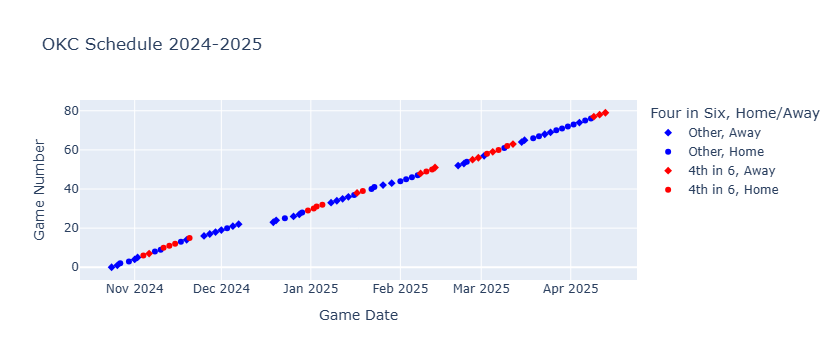

In [25]:
# Plot OKC Scatter
fig = px.scatter(
    scheduleOKC,
    x="gamedate",
    color="Four in Six", # Color represents 4-in-6 or not
    symbol="Home/Away",  # Symbols represents Home or Away
    color_discrete_map={'4th in 6': 'red', 'Other': 'blue'},
    symbol_map={'Home': 'circle', 'Away': 'diamond'},
    title="OKC Schedule 2024-2025",
)

# Update graph names
fig.update_xaxes(title="Game Date")
fig.update_yaxes(title="Game Number")
fig.show()

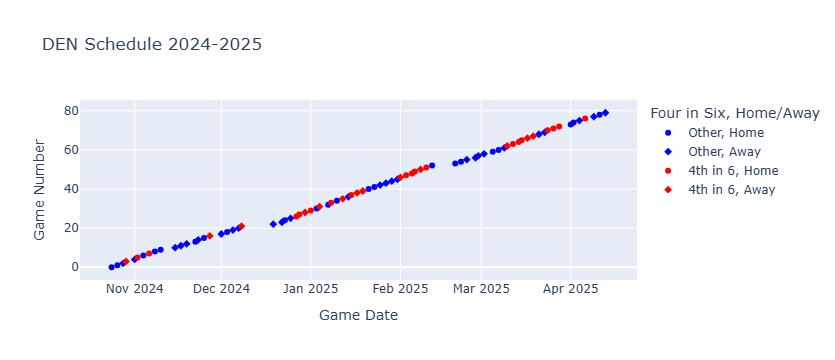

In [26]:
# Plot DEN Scatter
fig = px.scatter(
    scheduleDEN,
    x="gamedate",
    color="Four in Six", # Color represents 4-in-6 or not
    symbol="Home/Away",  # Symbols represents Home or Away
    color_discrete_map={'4th in 6': 'red', 'Other': 'blue'},
    symbol_map={'Home': 'circle', 'Away': 'diamond'},
    title="DEN Schedule 2024-2025",
)

# Update graph names
fig.update_xaxes(title="Game Date")
fig.update_yaxes(title="Game Number")
fig.show()

<strong><span style="color:red">ANSWER 7:</span></strong> Above, I created scatterplots representing the schedule of OKC and DEN in the 2024-2025 season. You can explore the graph interactively by directly clicking and dragging on the plot and double-click to reset to the original view. Red dots indicate 4th games in 6 day stretches (reference to Q1-3). Blue dots indicate games that do not indicate 4-in-6 strethces. Diamonds indicate away games and circles indicate home games. 
<br>If I had more data to spent on this, the next chart I'd work on is a gantt chart where I can introduce additional bars that represent distance traveled or plane flight times if OKC/DEN is either traveling between a home-to-away game, away-to-away game, or away-to-home game. This could help staff prepare for long streaks of plane flights.

### Question 8    

**QUESTION:** Using your tool, what is the best and worst part of OKC’s 2024-25 draft schedule? Please give your answer as a short brief to members of the front office and coaching staff to set expectations going into the season. You can include context from past schedules.  



<strong><span style="color:red">ANSWER 8:</span></strong> The **worst** dates, according to the plot above, will be the red marked games. It's especially bad if there's several that happen in a row. For example, February 26th - March 12th contains seven out of nine 4-in-6 games. Other periods include early January and late February where there's a similar pattern of red games.

Red indicates it's at least the 4th game in the past 6 nights, indicating denser game periods, which is a known point for **athletic fatigue and high travel** frequency, which has been historically known to be harmful for game performance and injury risk. These periods will require special attention to player recovery, and possibly considering rotational depth. I would advise to attention to load management, rest, and wellness. 

On a side note, if certain players grow susceptible due to **jet lag and travel burden**, weeks where several, back-to-back diamonds (when team is traveling) would prove tough. For example, November 25th - December 7th will have lots of traveling away-from-home. Staff should focus on aiding players for long, continuous flights.

The **best** dates would typically be around late January or early April where there are only 6-7 blue games in a row. Where the team can have long runs with ideal rest periods for performance and recovery. Gaps or stretches of blue can mark when OKC will have lower injury risk, player load, and possible condition advantages. 

These **low 4-in-6 clusters** will be good opportunities for OKC to rest, have extra practice, and making more major adjustments to team strategy, roster, and etc. These gaps can mark valuable times for staff to come together to discuss integrating extra trades/signings or introducing new defensive/offensive builds. 

## Part 3 -- Modeling     

### Question 9   

**QUESTION:** Please estimate how many more/fewer regular season wins each team has had due to schedule-related factors from 2019-20 though 2023-24. Your final answer should have one number for each team, representing the total number of wins (not per 82, and not a per-season average). You may consider the on-court strength of the scheduled opponents as well as the impact of travel/schedule density. Please include the teams and estimates for the most helped and most hurt in the answer key.    

If you fit a model to help answer this question, please write a paragraph explaining your model, and include a simple model diagnostic (eg a printed summary of a regression, a variable importance plot, etc).    

Elo Formula Reference(pg 18): https://digitalcommons.bryant.edu/cgi/viewcontent.cgi?article=1000&context=honors_data_science

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
### Feature Engineering

# Filter regular season games and seasons after 2019 (that is what we're analyzing)
game_data = game_data[(game_data['gametype'] == 2) & (game_data['season'] >= 2019)]

# Create df with cum wins per team-season
wins = game_data.groupby(['season', 'off_team'])['off_win'].sum().reset_index(name='total_wins')

# Create df with average opponent win rate per team-season (include list of opponents) 
games = schedule[(schedule['season'] >= 2019)]
opponents = games.groupby(['season', 'team'])['opponent'].apply(list).reset_index()
# Compute each opponent's win% (excluding games vs select team)
# Function generated with ChatGPT
def opponent_win_pct(season, opp_team):
    opp_games = game_data[(game_data['season'] == season) & 
                          (game_data['off_team'] == opp_team)]
    return opp_games['off_win'].mean()

opponents['avg_opp_win_pct'] = opponents.apply(
    lambda row: np.mean([opponent_win_pct(row['season'], opp) for opp in row['opponent']]), axis=1
)

# Create df with counts of back 2 backs per team-season
schedule['gamedate'] = pd.to_datetime(schedule['gamedate'])
schedule = schedule.sort_values(['team', 'gamedate'])
schedule['prev_date'] = schedule.groupby('team')['gamedate'].shift(1)
schedule['b2b'] = (schedule['gamedate'] - schedule['prev_date']).dt.days == 1
b2bs = schedule.groupby(['season', 'team'])['b2b'].sum().reset_index(name='num_b2b')

# Filter df from previous question on four_in_six and travel distance to include into model
four_in_six = per_82[per_82['season'] >= 2019]
travel_by_season = travel_by_season[travel_by_season['season'] >= 2019]

In [29]:
### New Features Schema
# Merge on wins and opponents on season and offensive team (perspective team).
# Next merge on df and b2b on season and offensive team.
# Next merge on df and four_in_six on season and team. (do same thing for travel_by_season)
print(wins.columns)
print(opponents.columns)
print(b2bs.columns)
print(four_in_six.columns)
print(travel_by_season.columns)

Index(['season', 'off_team', 'total_wins'], dtype='object')
Index(['season', 'team', 'opponent', 'avg_opp_win_pct'], dtype='object')
Index(['season', 'team', 'num_b2b'], dtype='object')
Index(['team', 'season', 'games_played', 'four_in_6', 'four_in_6_per82'], dtype='object')
Index(['team', 'season', 'travel_miles'], dtype='object')


In [30]:
# Merge dataset according to above cell's logic.
df = (
    wins.rename(columns={'off_team':'team'})
    .merge(opponents[['season', 'team', 'avg_opp_win_pct']], on=['season', 'team'], how='left')
    .merge(b2bs[['season', 'team', 'num_b2b']], on=['season', 'team'], how='left')
    .merge(four_in_six[['season', 'team', 'four_in_6']], on=['season', 'team'], how='left')
    #.merge(travel_by_season[['season', 'team', 'travel_miles']], on=['season', 'team'], how='left')
)
df.head()

,season,team,total_wins,avg_opp_win_pct,num_b2b,four_in_6
0,2019,ATL,20,0.509634,12,18
1,2019,BKN,35,0.491274,10,15
2,2019,BOS,48,0.491832,10,15
3,2019,CHA,23,0.489358,11,20
4,2019,CHI,22,0.476204,9,22


In [31]:
# Target: total wins (Y)
# Predictors: (X)
X = df[['avg_opp_win_pct', 'num_b2b', 'four_in_6']]
y = df['total_wins']

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)

# Coefficients and intercept
print('Intercept:', round(model.intercept_,3))
for name, coef in zip(X.columns, model.coef_):
    print(f'{name}: {round(coef,3)}')
print('R^2 Score:', round(model.score(X, y),3)) # Check R-squared score 

Intercept: 388.359
avg_opp_win_pct: -708.195
num_b2b: 1.251
four_in_6: -0.516
R^2 Score: 0.304


In [32]:
intercept = 388.359
coef_opp = -708.195
coef_b2b = 1.251
coef_four_in_6 = -0.516
#ceof_travel_miles = 0.001
# Calculate league-average attributes in schedule
avg_opp_avg = df['avg_opp_win_pct'].mean()
avg_b2b_avg = df['num_b2b'].mean()
avg_4in6_avg = df['four_in_6'].mean()

# Predicted wins with real schedule
df['predicted_wins'] = intercept + coef_opp * df['avg_opp_win_pct'] + coef_b2b * df['num_b2b'] + coef_four_in_6 * df['four_in_6']

# Predicted wins with baseline (average) schedule
df['baseline_wins'] = intercept + (coef_opp * avg_opp_avg) + (coef_b2b * avg_b2b_avg) + (coef_four_in_6 * avg_4in6_avg)
# Calculate schedule impact (difference)
df['win_impact'] = df['predicted_wins'] - df['baseline_wins']
df['wins_if_average_schedule'] = df['total_wins'] - df['win_impact']
df = df.sort_values('win_impact')
df[['team', 'total_wins', 'win_impact', 'wins_if_average_schedule']].head(3)

,team,total_wins,win_impact,wins_if_average_schedule
144,POR,21,-17.328983,38.328983
148,UTA,31,-15.136161,46.136161
146,SAS,22,-14.767954,36.767954


In [33]:
# Sum impact across seasons for each team
total_impact = df.groupby('team')['win_impact'].sum().reset_index(name='total_impact').sort_values('total_impact')
# Take top positively and negatively impacted teams (2019-2024)
print(total_impact.head(1))
print(total_impact.tail(1))

   team  total_impact
26  SAS    -36.297041
   team  total_impact
16  MIL     36.614471


<strong><span style="color:red">ANSWER 9:</span></strong>  

- Most Helped by Schedule: MIL (36.6 wins)     
- Most Hurt by Schedule: SAS (-36.29 wins)    

This model aims at quantifying and observing how **scheduling factors into hurting/helping** NBA teams. The model uses features including team-season wins, opponent strength (win rate), and days to evaluate the amount of games teams loss due to disadvantageous scheduling. At it's core, it uses average opponent win rate and count of back to back games inside sci-kit learn. 

The model **estimates games won or lost** due to scheduling. If you refer to the coefficients above, I found a high negative coefficient with average opponent win percentage. This suggests that opponents that win more often mean a tougher schedule, which is intuitive because stronger opponents = higher chance to lose. I noticed a small coefficient with back to back games, which potentially could be another point of interest in future projects. The model's R^2 means it accounts for about 30.4% of variance in model output, which is acceptable since there are a lot of in game factors (player health, time of season, etc.) and random noise that can influence team wins. 

Schedule impact metrics for team-season win estimations were produced by comparing the actual inputs and league average inputs for the 2019-2023 seasons which created the baselines that produced the **total_impact** feature.

It's worth noting this **model has limitations** as it's only reliant on three variables. I'd suggest improving it by including new features such as injury reports, days away from home, and changes in timezones - to create a more sophisticated model with 6-7 features and stronger correlations. If this project had a longer due date, I'd prioritize developing more nuance to "opponent_strength" or "elo" attributes in comparison to current team-season observations that's discussed in the research paper I linked above. Additionally, I'd strongly recomend try 4-rather than 1-fold cross-validation to check if modeling error changes. 

**Final Notes**: 
<br>Dear Data Science @ OKC,
<br>I want to thank you all for the chance to apply and work on this project! I loved this challenge to engage and dig through basketball analytics. I appreciate the time and effort your team went through to put together this project and the environment to show my skills. I glad to see through this project how much OKC values cares for its athletes and staff. Regardless on how things turn out, I'm thankful for this experience and the chance to potentially a part of your organization. 
<br><br> Best, 
<br><br> Andrew Dai                                                                                                                        

<strong><span style="color:black">Sources Cited:</span></strong>  

Houde, M. “Predicting the Outcome of NBA Games.” Bryant University Honors Data Science, Bryant University, 2021, digitalcommons.bryant.edu/honors_data_science/1000 .

“Windowing Operations.” pandas 2.3.2 Documentation, pandas-dev, 2025, https://pandas.pydata.org/docs/whatsnew/v2.3.2.html .

“Plotly Express in Python.” Plotly, Plotly Technologies Inc., 2025, https://plotly.com/python/plotly-express/ .

Norouzi, Narges, and Josh Grossman. Data 100: Principles and Techniques of Data Science. UC Berkeley, Spring 2025, https://ds100.org/sp25/.

Khan, Ani, et al. Data 8: Foundations of Data Science. UC Berkeley, Fall 2023, https://www.data8.org/fa23/.